# 案例三：Drug Synergy 课堂教学 Notebook

对应脚本：`drug synergy/run_demo.py`

本案例聚焦药物组合协同效应预测任务，课堂主线如下：

1. 认识药物、细胞系和组合协同分数之间的关系
2. 理解异构图神经网络如何整合三元组信息
3. 观察回归模型在测试集上的训练与预测效果
4. 用课后作业引导学生继续扩展模型与指标


## 教学目标

完成这份 Notebook 后，应该能回答下面三个问题：

1. 为什么药物协同预测适合建成异构图，而不是只用普通表格回归？
2. 模型为什么要同时读取两个药物和一个细胞系的表示？
3. 在协同分数预测中，为什么要同时关注误差指标和相关性指标？


In [1]:
from pathlib import Path
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero
import torch_geometric.transforms as T

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "drug synergy" / "data"
RESULTS_DIR = PROJECT_ROOT / "drug synergy" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
HIDDEN_DIM = 64
LEARNING_RATE = 0.005
BATCH_SIZE = 32
EPOCHS = 10
TRAIN_RATIO = 0.8

print("项目根目录:", PROJECT_ROOT)
print("数据目录:", DATA_DIR)
print("结果目录:", RESULTS_DIR)
print(f"参数配置: hidden_dim={HIDDEN_DIM}, lr={LEARNING_RATE}, batch_size={BATCH_SIZE}, epochs={EPOCHS}")


项目根目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2
数据目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug synergy\data
结果目录: C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug synergy\results
参数配置: hidden_dim=64, lr=0.005, batch_size=32, epochs=10


## 1. 方法准备

本案例沿用 `run_demo.py` 的核心思路：

1. 构建药物-细胞系异构图
2. 用 GraphSAGE 聚合结构信息
3. 用 `[drugA, drugB, cell]` 三元组联合表示样本
4. 用 MLP 回归预测协同分数

课堂上建议把重点放在“为什么要这样建模”，而不是只关注代码实现。


In [3]:
# 本 Notebook 中使用的核心流程包括：
# 1. 构建药物-细胞系异构图
# 2. 用 GraphSAGE 提取节点表示
# 3. 拼接两个药物和一个细胞系的嵌入
# 4. 用 MLP 预测协同分数


## 2. 数据与任务认识

这一节建议先把样本和图结构讲清楚：

1. 一个样本由两个药物和一个细胞系组成
2. 每个药物节点带有分子指纹特征
3. 每个细胞系节点带有表达谱特征
4. 输出目标是连续的协同分数，因此这是回归任务


In [4]:
summary_df


    项目   数值
 药物节点数   19
细胞系节点数    8
 组合样本数 1392
药物特征维度 1024
细胞特征维度  978
训练集样本数 1113
测试集样本数  279

## 3. 模型输入准备

在正式训练前，需要先明确三件事：

1. 原始组合数据是什么样子
2. 异构图缓存是如何被加载的
3. 训练集和测试集是如何划分的

只有把这些输入准备讲清楚，学生才能理解模型为什么能进行三元组回归预测。


In [5]:
print(stage1_text)
print(stage2_text)
display(combo_preview)


阶段1: 数据与异构图准备
药物节点数          : 19
细胞系节点数        : 8
药物原始特征维度    : 1024
细胞系原始特征维度  : 978
组合样本总数        : 1392
图中的关系类型      : [('drug', 'interacts', 'cell'), ('cell', 'rev_interacts', 'drug')]
阶段2: 数据集划分
训练集样本数        : 1113
测试集样本数        : 279
批大小              : 32
训练轮数            : 10


 drug_row  drug_col  cell_line_name  synergy_loewe
     1938      3297              51      -8.110536
     1938       595              51      -2.458491
     1938      3361              51     -10.540838
     1938      4175              51      -4.485098
     1938      2852              51     -13.015462

## 4. 模型训练过程

这一节重点不是记住每层网络，而是理解整个计算链路：

1. 先把药物和细胞系投影到同一隐藏空间
2. 再通过异构 GraphSAGE 进行消息传递
3. 最后把两个药物和一个细胞系的表示拼接后送入 MLP

建议重点观察训练集和测试集 `MSE` 的变化趋势。


In [6]:
print(train_log_text)
history_df


阶段3: 模型训练
Epoch 01 | Train MSE = 75.4096 | Test MSE = 44.9890
Epoch 02 | Train MSE = 62.6144 | Test MSE = 49.0110
Epoch 03 | Train MSE = 65.9992 | Test MSE = 49.6771
Epoch 04 | Train MSE = 56.5834 | Test MSE = 36.3568
Epoch 05 | Train MSE = 49.4860 | Test MSE = 36.1339
Epoch 06 | Train MSE = 47.8394 | Test MSE = 35.8989
Epoch 07 | Train MSE = 47.4566 | Test MSE = 34.3231
Epoch 08 | Train MSE = 47.7697 | Test MSE = 35.0569
Epoch 09 | Train MSE = 47.5789 | Test MSE = 37.4783
Epoch 10 | Train MSE = 49.5885 | Test MSE = 34.7288


 epoch  train_mse  test_mse
     1  75.409624 44.988992
     2  62.614426 49.011007
     3  65.999179 49.677147
     4  56.583440 36.356802
     5  49.486036 36.133898
     6  47.839420 35.898897
     7  47.456624 34.323098
     8  47.769711 35.056921
     9  47.578881 37.478256
    10  49.588543 34.728797

## 5. 测试集结果与指标解释

因为这是回归任务，这里不再使用 `AUC`，而是关注：

1. `MAE`：平均绝对误差
2. `RMSE`：均方根误差
3. `Pearson`：预测值与真实值的线性相关性

课堂上可以讨论：相关性较高是否一定意味着误差也足够小？


阶段4: 测试集结果分析
MAE                 : 4.4656
RMSE                : 5.8931
Pearson Correlation : 0.4863
模型权重已保存至    : C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug synergy\data\macro_hetero_model.pth
预测结果已保存至    : C:\Users\Steve\Desktop\Research\Book\code\Chapter6\6_2\drug synergy\data\test_predictions.csv


     MAE     RMSE  Pearson
4.465558 5.893115 0.486291

 True_Synergy  Predicted_Synergy
   -16.547197          -8.592656
    -4.422631          -5.239552
    -5.137098          -6.789114
     0.131506           0.349730
    -7.316475          -5.862032

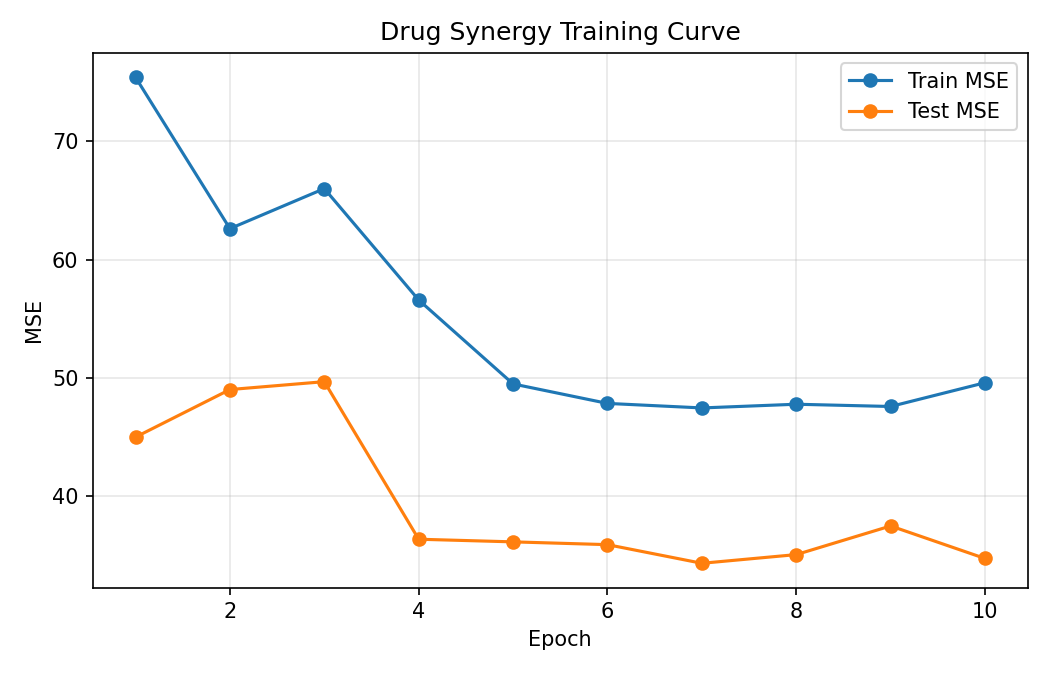

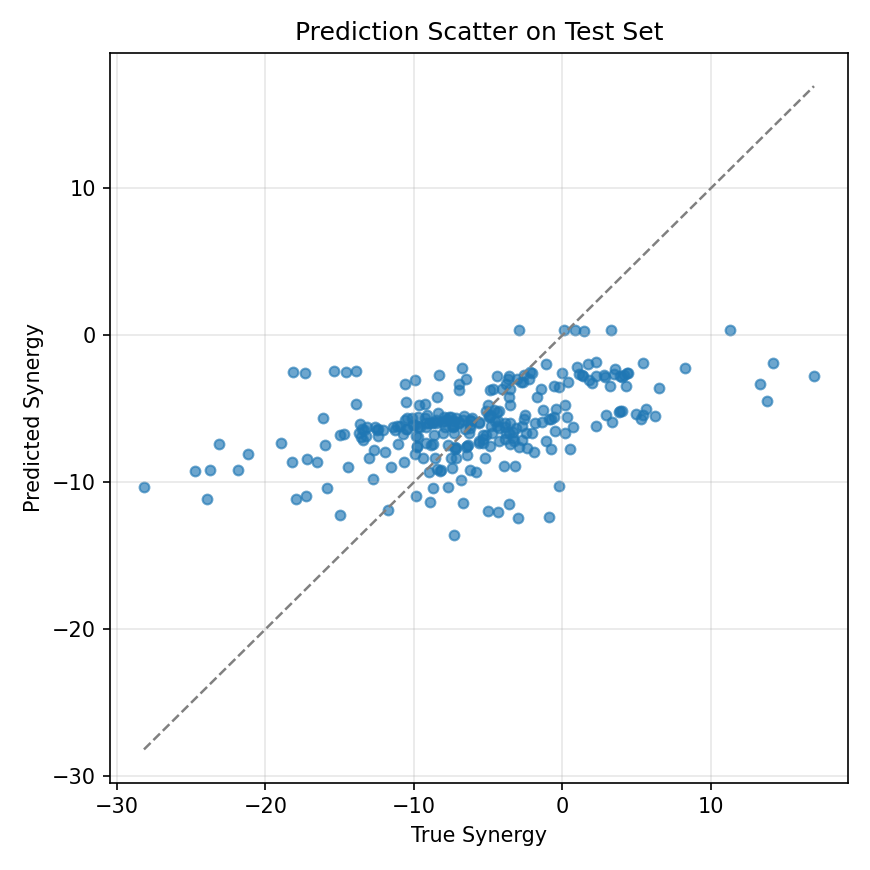

In [7]:
print(stage4_text)
metrics_df
display(results_df)


## 6. 可视化结果解读

这里展示两类图像：

1. 训练曲线：观察模型是否逐步收敛
2. 预测散点图：观察预测值与真实值是否保持一致趋势

这两张图一起看，比只看单个数字更容易理解模型状态。


In [ ]:
# 下面两张图已经在后台生成


## 7. 课堂总结

这一案例展示了异构图神经网络在药物协同预测中的一个基础范式：

1. 用异构图统一表示药物和细胞系
2. 用图神经网络聚合结构信息
3. 用三元组回归方式预测协同分数
4. 用误差指标和相关性共同分析模型表现

从当前实验结果看，模型已经能够学到一定的协同趋势，但仍然有比较明显的改进空间。


## 8. 课后作业

请从下面几个方向继续完成练习：

1. 实现一个新的评价指标，例如 `R^2`
2. 比较不同 `hidden_dim` 对训练曲线和测试误差的影响
3. 思考为什么这里把药物组合拆成两条 `drug -> cell` 边，而不是显式构造组合节点
4. 尝试把每个 epoch 的训练结果自动保存成 CSV
5. 思考如果加入药物-药物相似性边或细胞系相似性边，图结构应该如何扩展
